In [20]:
import pyarrow as pa
import pyarrow.ipc as ipc

import io
import struct

import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [21]:
BASE_DIR = Path.cwd().parent

RESULTS_DIR = (
    BASE_DIR /
    "results" /
    "memory_layout_visualization"
)

GRAPHS_DIR = RESULTS_DIR / "graphs"
TABLES_DIR = RESULTS_DIR / "tables"
LOGS_DIR = RESULTS_DIR / "logs"

GRAPHS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

LOGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(f"Results directory: {RESULTS_DIR}")

Results directory: /home/megh/arrow-ipc-analysis-linux/results/memory_layout_visualization


In [22]:
print("\n" + "="*80)
print("PRIMITIVE ARRAY")
print("="*80)

primitive = pa.array(
    [1, 2, None, 4, 5],
    type=pa.int64()
)

print("Array:")
print(primitive)

print("\nBuffers:")

primitive_buffers = primitive.buffers()

for i, buf in enumerate(primitive_buffers):

    print(f"\nBuffer {i}")

    if buf is None:
        print("None")
        continue

    print(f"Size    : {buf.size} bytes")
    print(f"Address : {hex(buf.address)}")

    raw = buf.to_pybytes()

    print(f"Raw Bytes: {raw[:32]}")


PRIMITIVE ARRAY
Array:
[
  1,
  2,
  null,
  4,
  5
]

Buffers:

Buffer 0
Size    : 1 bytes
Address : 0x758492690c00
Raw Bytes: b'\x1b'

Buffer 1
Size    : 40 bytes
Address : 0x758492690c80
Raw Bytes: b'\x01\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x00\x00\x00\x00\x00'


In [23]:
print("\n" + "="*80)
print("LIST ARRAY")
print("="*80)

list_array = pa.array([
    [1, 2],
    [3],
    None,
    [4, 5, 6]
])

print("Array:")
print(list_array)

print("\nBuffers:")

list_buffers = list_array.buffers()

for i, buf in enumerate(list_buffers):

    print(f"\nBuffer {i}")

    if buf is None:
        print("None")
        continue

    print(f"Size    : {buf.size} bytes")
    print(f"Address : {hex(buf.address)}")

    raw = buf.to_pybytes()

    print(f"Raw Bytes: {raw[:32]}")


LIST ARRAY
Array:
[
  [
    1,
    2
  ],
  [
    3
  ],
  null,
  [
    4,
    5,
    6
  ]
]

Buffers:

Buffer 0
Size    : 1 bytes
Address : 0x758492690dc0
Raw Bytes: b'\x0b'

Buffer 1
Size    : 20 bytes
Address : 0x758492690d40
Raw Bytes: b'\x00\x00\x00\x00\x02\x00\x00\x00\x03\x00\x00\x00\x03\x00\x00\x00\x06\x00\x00\x00'

Buffer 2
None

Buffer 3
Size    : 48 bytes
Address : 0x758492690f00
Raw Bytes: b'\x01\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x03\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x00\x00\x00\x00\x00'


In [24]:
print("\n" + "="*80)
print("STRUCT ARRAY")
print("="*80)

struct_array = pa.array([
    {"x": 1, "y": 1.5},
    {"x": 2, "y": 2.5},
    None,
    {"x": 4, "y": 4.5}
])

print("Array:")
print(struct_array)

print("\nBuffers:")

struct_buffers = struct_array.buffers()

for i, buf in enumerate(struct_buffers):

    print(f"\nBuffer {i}")

    if buf is None:
        print("None")
        continue

    print(f"Size    : {buf.size} bytes")
    print(f"Address : {hex(buf.address)}")

    raw = buf.to_pybytes()

    print(f"Raw Bytes: {raw[:32]}")


STRUCT ARRAY
Array:
-- is_valid:
  [
    true,
    true,
    false,
    true
  ]
-- child 0 type: int64
  [
    1,
    2,
    0,
    4
  ]
-- child 1 type: double
  [
    1.5,
    2.5,
    0,
    4.5
  ]

Buffers:

Buffer 0
Size    : 1 bytes
Address : 0x758492690fc0
Raw Bytes: b'\x0b'

Buffer 1
None

Buffer 2
Size    : 32 bytes
Address : 0x7584926903c0
Raw Bytes: b'\x01\x00\x00\x00\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x00\x00\x00\x00\x00\x00\x00'

Buffer 3
None

Buffer 4
Size    : 32 bytes
Address : 0x758492690e80
Raw Bytes: b'\x00\x00\x00\x00\x00\x00\xf8?\x00\x00\x00\x00\x00\x00\x04@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x12@'


In [25]:
print("\n" + "="*80)
print("ZERO-COPY SLICE")
print("="*80)

base_array = pa.array(range(20))

slice_view = base_array.slice(5, 10)

print("Base Array:")
print(base_array)

print("\nSlice View:")
print(slice_view)

base_buffer = base_array.buffers()[1]
slice_buffer = slice_view.buffers()[1]

print("\nMemory Addresses")

print(
    f"Base Buffer Address  : "
    f"{hex(base_buffer.address)}"
)

print(
    f"Slice Buffer Address : "
    f"{hex(slice_buffer.address)}"
)

print(
    "\nShares Memory:",
    base_buffer.address == slice_buffer.address
)


ZERO-COPY SLICE
Base Array:
[
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19
]

Slice View:
[
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14
]

Memory Addresses
Base Buffer Address  : 0x758492680e40
Slice Buffer Address : 0x758492680e40

Shares Memory: True


In [26]:
print("\n" + "="*80)
print("IPC SERIALIZATION")
print("="*80)

table = pa.table({
    "numbers": primitive
})

sink = io.BytesIO()

writer = ipc.new_stream(
    sink,
    table.schema
)

writer.write_table(table)

writer.close()

serialized = sink.getvalue()

print(f"Serialized Size: {len(serialized)} bytes")


IPC SERIALIZATION
Serialized Size: 336 bytes


In [27]:
print("\nFirst 128 Serialized Bytes:\n")

hex_dump = serialized[:128].hex()

for i in range(0, len(hex_dump), 32):

    chunk = hex_dump[i:i+32]

    print(chunk)


First 128 Serialized Bytes:

ffffffff800000001000000000000a00
0c000600050008000a00000000010400
0c000000080008000000040008000000
04000000010000001400000010001400
0800060007000c000000100010000000
00000102100000002000000004000000
00000000070000006e756d6265727300
08000c00080007000800000000000001


In [28]:
print("\n" + "="*80)
print("IPC STREAM MARKERS")
print("="*80)

print("First 16 bytes:")

first_16 = serialized[:16]

print(first_16)

print("\nAs integers:")

print(list(first_16))


IPC STREAM MARKERS
First 16 bytes:
b'\xff\xff\xff\xff\x80\x00\x00\x00\x10\x00\x00\x00\x00\x00\n\x00'

As integers:
[255, 255, 255, 255, 128, 0, 0, 0, 16, 0, 0, 0, 0, 0, 10, 0]


In [29]:
print("\n" + "="*80)
print("DESERIALIZATION")
print("="*80)

reader = ipc.open_stream(serialized)

recovered = reader.read_all()

print(recovered)


DESERIALIZATION
pyarrow.Table
numbers: int64
----
numbers: [[1,2,null,4,5]]


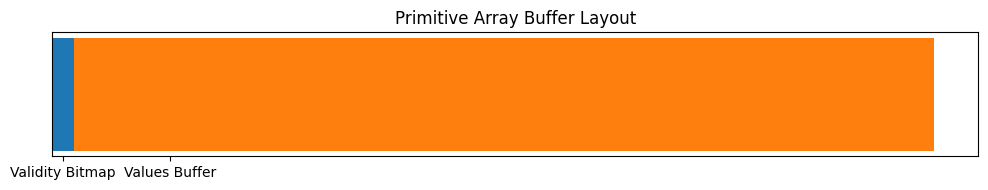

In [38]:
plt.figure(figsize=(10, 2))
values_size = primitive_buffers[1].size
bitmap_size = primitive_buffers[0].size
plt.barh(
    [0],
    [bitmap_size],
    left=[0],
    height=0.5
)

plt.barh(
    [0],
    [values_size],
    left=[bitmap_size],
    height=0.5
)

plt.yticks([])

plt.xticks(
    [0.5, 5.5],
    ["Validity Bitmap", "Values Buffer"]
)

plt.title("Primitive Array Buffer Layout")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "primitive_layout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

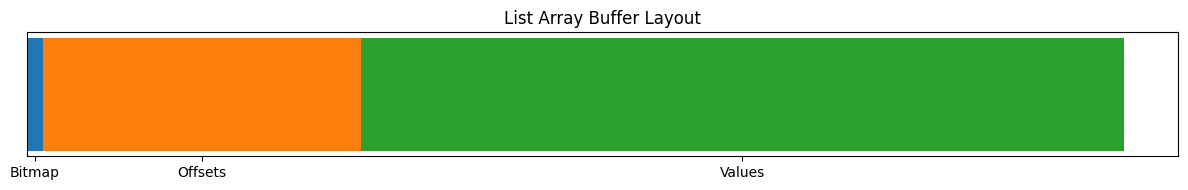

In [31]:
plt.figure(figsize=(12, 2))

bitmap_size = list_buffers[0].size
offset_size = list_buffers[1].size
values_size = list_buffers[3].size

plt.barh(
    [0],
    [bitmap_size],
    left=[0],
    height=0.5
)

plt.barh(
    [0],
    [offset_size],
    left=[bitmap_size],
    height=0.5
)

plt.barh(
    [0],
    [values_size],
    left=[bitmap_size + offset_size],
    height=0.5
)

plt.yticks([])

plt.xticks(
    [
        bitmap_size / 2,

        bitmap_size + (offset_size / 2),

        bitmap_size + offset_size +
        (values_size / 2)
    ],
    [
        "Bitmap",
        "Offsets",
        "Values"
    ]
)

plt.title("List Array Buffer Layout")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "list_layout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

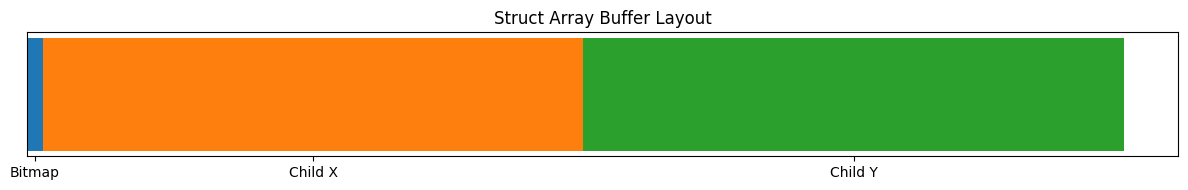

In [32]:
plt.figure(figsize=(12, 2))

bitmap_size = struct_buffers[0].size
child_x_size = struct_buffers[2].size
child_y_size = struct_buffers[4].size

plt.barh(
    [0],
    [bitmap_size],
    left=[0],
    height=0.5
)

plt.barh(
    [0],
    [child_x_size],
    left=[bitmap_size],
    height=0.5
)

plt.barh(
    [0],
    [child_y_size],
    left=[bitmap_size + child_x_size],
    height=0.5
)

plt.yticks([])

plt.xticks(
    [
        bitmap_size / 2,

        bitmap_size + (child_x_size / 2),

        bitmap_size + child_x_size +
        (child_y_size / 2)
    ],
    [
        "Bitmap",
        "Child X",
        "Child Y"
    ]
)

plt.title("Struct Array Buffer Layout")

plt.tight_layout()

plt.savefig(
    GRAPHS_DIR / "struct_layout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
summary = pd.DataFrame({
    "Structure": [
        "Primitive",
        "List",
        "Struct"
    ],

    "Buffer_Count": [
        len(primitive_buffers),
        len(list_buffers),
        len(struct_buffers)
    ]
})

summary

,Structure,Buffer_Count
0,Primitive,2
1,List,4
2,Struct,5


In [34]:
csv_path = (
    TABLES_DIR /
    "buffer_summary.csv"
)

summary.to_csv(
    csv_path,
    index=False
)

print(f"\nSaved CSV:\n{csv_path}")


Saved CSV:
/home/megh/arrow-ipc-analysis-linux/results/memory_layout_visualization/tables/buffer_summary.csv


In [35]:
hex_path = (
    LOGS_DIR /
    "serialized_hex_dump.txt"
)

with open(hex_path, "w") as f:

    for i in range(0, len(hex_dump), 32):

        chunk = hex_dump[i:i+32]

        f.write(chunk + "\n")

print(f"\nSaved hex dump:\n{hex_path}")


Saved hex dump:
/home/megh/arrow-ipc-analysis-linux/results/memory_layout_visualization/logs/serialized_hex_dump.txt
